<a href="https://colab.research.google.com/github/SekaniDev/te-portfolio/blob/main/Validator_game_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nashpy -q

import numpy as np
import nashpy as nash
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("numpy", np.__version__, "| nashpy", nash.__version__)

numpy 2.1.3 | nashpy 0.0.43


In [ ]:
# Parameters
R = 5     # reward for honest staking
B = 10    # bribe / MEV for defecting against an honest validator
M = 0     # payoff for staking while the other defects
S = 15    # loss each validator takes if both defect

# Validator A's payoffs (rows = A's action, columns = B's action)
#            B: Stake  B: Defect
A_pay = np.array([[R,     M],       # A stakes
                  [B,    -S]])      # A defects

# Validator B's payoffs
B_pay = A_pay.T

print("A:\n", A_pay)
print("B:\n", B_pay)

A:
 [[  5   0]
 [ 10 -15]]
B:
 [[  5  10]
 [  0 -15]]


In [ ]:
actions = ["Stake", "Defect"]

def pure_nash(A, B):
    eqs = []
    for i in range(2):          # A's action
        for j in range(2):      # B's action
            a_happy = A[i, j] >= A[1 - i, j]   # A can't gain by switching rows
            b_happy = B[i, j] >= B[i, 1 - j]   # B can't gain by switching columns
            if a_happy and b_happy:
                eqs.append((i, j))
    return eqs

for i, j in pure_nash(A_pay, B_pay):
    print(f"Pure Nash Equilibrium: A: {actions[i]}, B: {actions[j]}")

Pure Nash Equilibrium: A: Stake, B: Defect
Pure Nash Equilibrium: A: Defect, B: Stake


In [ ]:
game = nash.Game(A_pay, B_pay)

for k, (a, b) in enumerate(game.support_enumeration(), 1):
    print(f"Equilibrium {k}")
    print(f"  A: Stake {a[0]:.0%}, Defect {a[1]:.0%}")
    print(f"  B: Stake {b[0]:.0%}, Defect {b[1]:.0%}")

Equilibrium 1
  A: Stake 100%, Defect 0%
  B: Stake 0%, Defect 100%
Equilibrium 2
  A: Stake 0%, Defect 100%
  B: Stake 100%, Defect 0%
Equilibrium 3
  A: Stake 75%, Defect 25%
  B: Stake 75%, Defect 25%


In [ ]:
def solve(slash):
    A = np.array([[R, M],
                  [B, -slash]])
    return list(nash.Game(A, A.T).support_enumeration())

for s in [5, 15, 45, 150]:
    eqs = solve(s)
    mixed = [a for a, b in eqs if 0 < a[0] < 1]
    print(f"S={s}: {len(eqs)} equilibria, mixed Stake prob = {mixed[0][0]:.0%}")

S=5: 3 equilibria, mixed Stake prob = 50%
S=15: 3 equilibria, mixed Stake prob = 75%
S=45: 3 equilibria, mixed Stake prob = 90%
S=150: 3 equilibria, mixed Stake prob = 97%


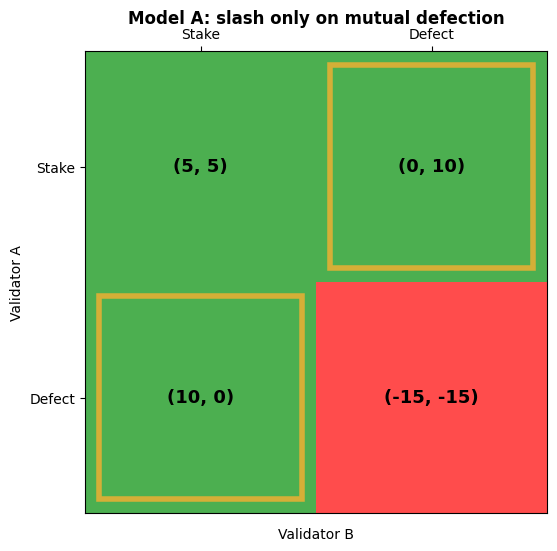

In [ ]:
def plot_heatmap(A, Bm, title="Validator payoff matrix", filename=None):
    welfare = A + Bm
    lo, hi = welfare.min(), welfare.max()
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "rg", ["#ff4c4c", "#e5e5e5", "#4caf50"]
    )
    norm = (
        mcolors.TwoSlopeNorm(vmin=lo, vcenter=0, vmax=hi)
        if lo < 0 < hi
        else mcolors.Normalize(vmin=lo, vmax=max(hi, lo + 1))
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(welfare, cmap=cmap, norm=norm)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"({A[i, j]}, {Bm[i, j]})",
                    ha="center", va="center", fontsize=13, fontweight="bold")

    # Gold box = pure Nash equilibrium (inset so neighbors don't merge)
    for i, j in pure_nash(A, Bm):
        ax.add_patch(plt.Rectangle((j - .44, i - .44), .88, .88, fill=False,
                                   edgecolor="#d4af37", linewidth=4))

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(actions); ax.set_yticklabels(actions)
    ax.xaxis.tick_top()
    ax.set_xlabel("Validator B", labelpad=10)
    ax.set_ylabel("Validator A")
    ax.set_title(title, pad=20, fontweight="bold")

    if filename:
        fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

plot_heatmap(A_pay, B_pay,
             "Model A: slash only on mutual defection",
             filename="model_a_heatmap.png")

Defect payoff: -2.0
Pure equilibria: [('Honest', 'Honest')]
Equilibrium 1: A=[1. 0.], B=[1. 0.]


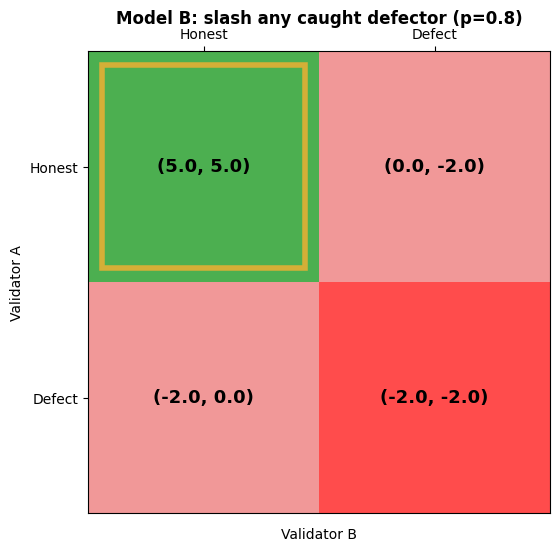

In [ ]:
import numpy as np
import nashpy as nash

# Define parameters if previous cells haven't been run
R = 5     # reward for honest staking
B = 10    # bribe / MEV for defecting against an honest validator
M = 0     # payoff for staking while the other defects
S = 15    # loss each validator takes if both defect

p = 0.8                      # probability a defector is caught
d = B - p * S                # expected payoff of defecting
print("Defect payoff:", d)

# Rows = A's action, columns = B's action (Honest, Defect)
A2 = np.array([[R, M],
               [d, d]])
B2 = A2.T

actions = ["Honest", "Defect"]   # relabel to match the new model

print("Pure equilibria:", [(actions[i], actions[j]) for i, j in pure_nash(A2, B2)])

for k, (a, b) in enumerate(nash.Game(A2, B2).support_enumeration(), 1):
    print(f"Equilibrium {k}: A={a.round(2)}, B={b.round(2)}")

    plot_heatmap(A2, B2, "Model B: slash any caught defector (p=0.8)",
                 filename="model_b_heatmap.png")

In [ ]:
for s in [0, 5, 7, 12, 13, 20]:
    d_s = B - p * s
    A_s = np.array([[R, M],
                    [d_s, d_s]])
    eqs = [(actions[i], actions[j]) for i, j in pure_nash(A_s, A_s.T)]
    print(f"S={s:>2}: defect payoff={d_s:5.2f}  {eqs}")

S= 0: defect payoff=10.00  [('Defect', 'Defect')]
S= 5: defect payoff= 6.00  [('Defect', 'Defect')]
S= 7: defect payoff= 4.40  [('Honest', 'Honest'), ('Defect', 'Defect')]
S=12: defect payoff= 0.40  [('Honest', 'Honest'), ('Defect', 'Defect')]
S=13: defect payoff=-0.40  [('Honest', 'Honest')]
S=20: defect payoff=-6.00  [('Honest', 'Honest')]


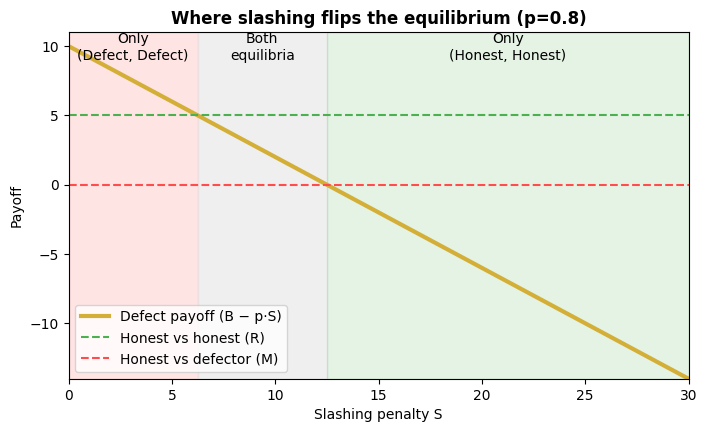

In [ ]:
ss = np.linspace(0, 30, 301)
t1, t2 = (B - R) / p, (B - M) / p      # 6.25 and 12.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(0, t1, color="#ff4c4c", alpha=.15)
ax.axvspan(t1, t2, color="#e5e5e5", alpha=.6)
ax.axvspan(t2, 30, color="#4caf50", alpha=.15)

ax.plot(ss, B - p * ss, color="#d4af37", lw=3, label="Defect payoff (B − p·S)")
ax.axhline(R, color="#4caf50", ls="--", label="Honest vs honest (R)")
ax.axhline(M, color="#ff4c4c", ls="--", label="Honest vs defector (M)")

ax.text(t1 / 2, 11, "Only\n(Defect, Defect)", ha="center", va="top")
ax.text((t1 + t2) / 2, 11, "Both\nequilibria", ha="center", va="top")
ax.text((t2 + 30) / 2, 11, "Only\n(Honest, Honest)", ha="center", va="top")

ax.set_xlim(0, 30); ax.set_ylim(-14, 11)
ax.set_xlabel("Slashing penalty S"); ax.set_ylabel("Payoff")
ax.set_title(f"Where slashing flips the equilibrium (p={p})", fontweight="bold")
ax.legend(loc="lower left")
fig.savefig("threshold_sweep.png", dpi=200, bbox_inches="tight")
plt.show()